In [1]:
!pip install earthpy gdal



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 57.9 MB/s eta 0:00:00:00:0100:01


In [5]:
from osgeo import gdal, gdal_array
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import io
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.optim as optim

mask_path="/kaggle/input/cloud-masking-dataset/content/train/masks"
data_path ="/kaggle/input/cloud-masking-dataset/content/train/data"



In [6]:
def display_image(file_name,data_only):
    file_path=os.path.join(data_path, file_name)
    img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
    num_bands=img_ds.RasterCount
    if( not data_only):
        fig, axs = plt.subplots(1, 5, figsize=(10, 5))
    else:
        fig, axs = plt.subplots(1, 4, figsize=(10, 5))
    
    for i in range(1,num_bands+1):
      band = img_ds.GetRasterBand(i)
      img = band.ReadAsArray()
      axs[i-1].imshow(img, cmap='gray')
      axs[i-1].set_title(f'Band {i}')
    if(not data_only):
        file_path=os.path.join(mask_path, file_name)
        img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
        num_bands=img_ds.RasterCount
        band = img_ds.GetRasterBand(1)
        img = band.ReadAsArray()
        axs[4].imshow(img, cmap='gray', vmin=0, vmax=1)        
        axs[4].set_title('Mask')
    plt.show()

***Display Random Images***

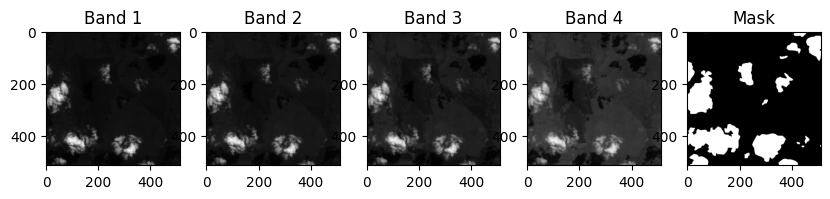

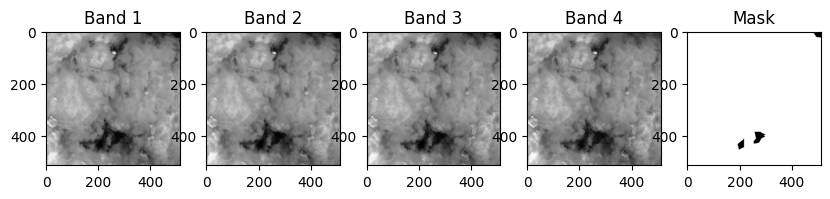

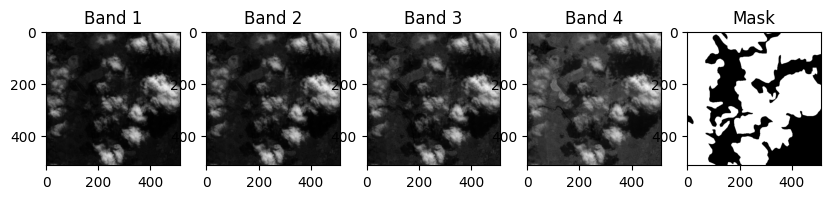

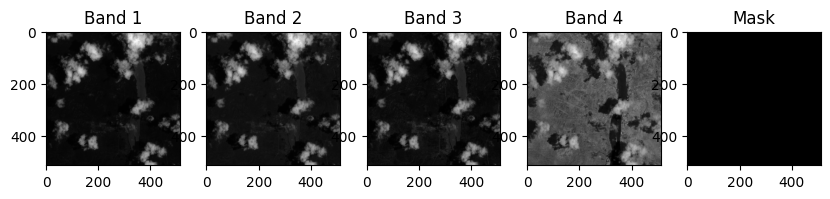

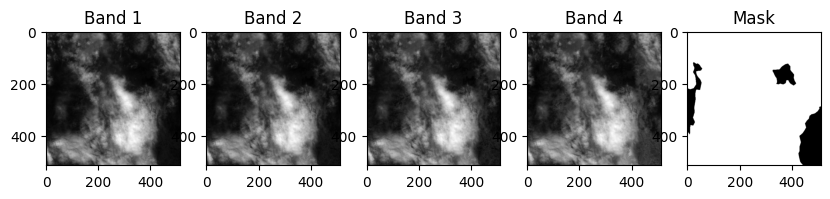

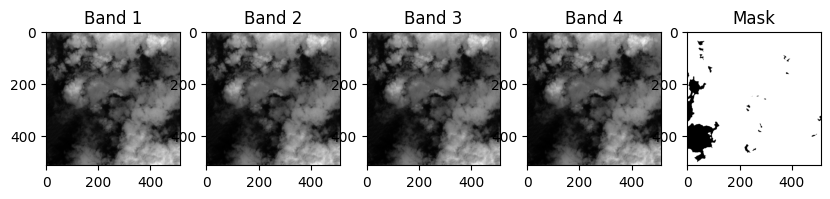

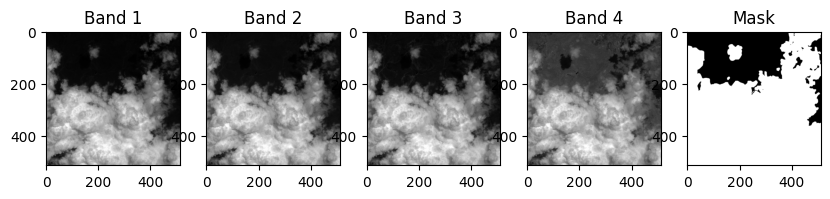

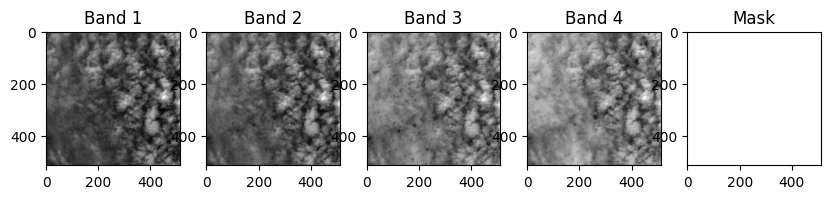

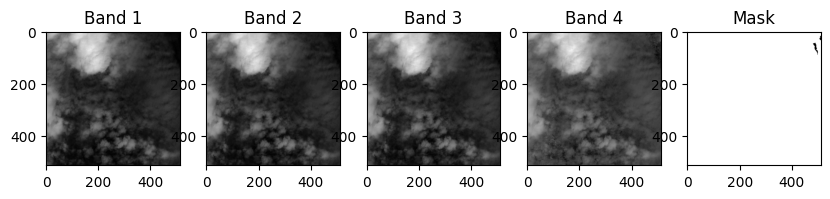

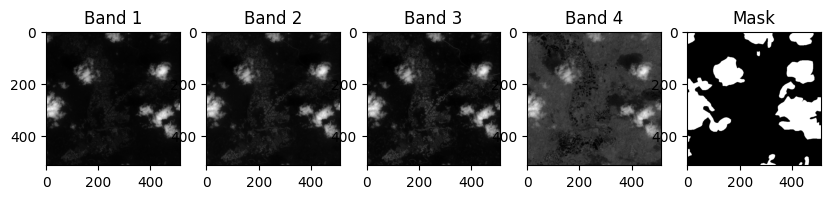

In [7]:

data= os.listdir(data_path)

train_data, val_test = train_test_split(data, test_size=0.2, random_state=42)
val, test = train_test_split(val_test, test_size=0.5, random_state=42)

random_indices = np.random.permutation(len(train_data))[:10]
for i in random_indices:
    file_name=train_data[i]
    display_image(file_name,False)

***Show Correlation Between Bands***

100%|██████████| 1000/1000 [00:47<00:00, 20.84it/s]


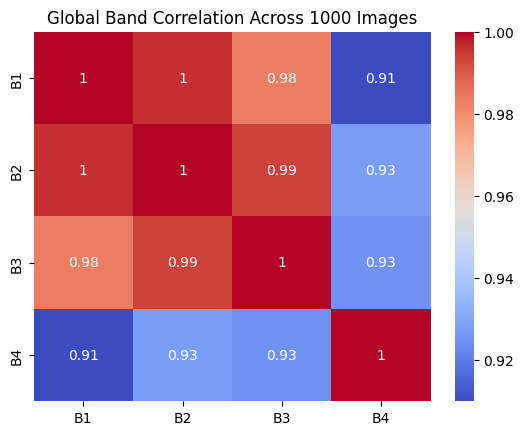

In [8]:
subset = random.sample(train_data, k=1000)
all_pixels = []
for file_path in tqdm(subset):
    file_path=os.path.join(data_path, file_path)
    img_ds = gdal.Open(file_path, gdal.GA_ReadOnly)
    width = img_ds.RasterXSize
    height = img_ds.RasterYSize
    num_bands = img_ds.RasterCount
    img_array = np.zeros((height, width, num_bands), dtype=np.float32)
    for i in range(num_bands):
        band = img_ds.GetRasterBand(i + 1)
        img_array[:, :, i] = band.ReadAsArray()
    reshaped = img_array.reshape(-1, 4)
    all_pixels.append(reshaped)

combined = np.vstack(all_pixels)  # Shape: (total_pixels, 4)
corr = np.corrcoef(combined.T)
sns.heatmap(corr, annot=True, cmap='coolwarm', xticklabels=['B1', 'B2', 'B3', 'B4'], yticklabels=['B1', 'B2', 'B3', 'B4'])
plt.title("Global Band Correlation Across 1000 Images")
plt.show()









***Apply PCA On Bands 3&4***

In [ ]:
subset = random.sample(train_data, k=1000)
images = []
for fname in subset:
    img_path = os.path.join(data_path, fname)
    img_ds = gdal.Open(img_path, gdal.GA_ReadOnly)
    for i in [3,4]:
        band = img_ds.GetRasterBand(i)
        img_array[:, :, i-3] = band.ReadAsArray()
    reshaped = img_array.reshape(-1, 2)
    images.append(reshaped)


X = np.vstack(images)  # Shape: (total_pixels, 2)

# Scale the data to have zero mean and unit variance along each feature axis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA with 3 components
pca = PCA()
pca.fit(X_scaled)
output = pca.transform(X_scaled)

# Scree plot of the eigen value ratios
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure()
plt.plot(explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.show()

# Plot the 3D graph of the PCA (scatter plot of first 3 principal components)
pc1 = output[:, 0]




# Save the fitted PCA model
# joblib.dump(pca, 'pca_model.joblib')
# joblib.dump(scaler, 'scaler_model.joblib')


# === Load Saved Models ===
pca = joblib.load('/kaggle/input/pca/other/default/1/pca_model.joblib')
scaler = joblib.load('/kaggle/input/pca/other/default/1/scaler_model.joblib')



In [ ]:
def apply_pca(file_name,is_file_name):
    # === Select and Load a New Image ===
    if(is_file_name):
        new_image_path = os.path.join(data_path, file_name)  # pick one test image
    else:
        new_image_path=file_name
        
    img_ds = gdal.Open(new_image_path, gdal.GA_ReadOnly)
    
    # === Read Band 3 and 4 ===
    band3 = img_ds.GetRasterBand(3).ReadAsArray()
    band4 = img_ds.GetRasterBand(4).ReadAsArray()
    
    # === Stack and Reshape ===
    img_array = np.stack([band3, band4], axis=-1)  # shape: (H, W, 2)
    h, w, _ = img_array.shape
    reshaped = img_array.reshape(-1, 2)
    
    # === Transform with Scaler and PCA ===
    scaled = scaler.transform(reshaped)
    pca_output = pca.transform(scaled)
    
    # === Select First Principal Component and Reshape to Image ===
    pc1 = pca_output[:, 0].reshape(h, w)

    # plt.figure(figsize=(10, 6))
    # plt.imshow(pc1, cmap='gray')
    # plt.colorbar()
    # plt.title('First Principal Component of New Image')
    # plt.axis('off')
    # plt.show()

    return pc1



***Show Counts***

838it [00:12, 72.05it/s]

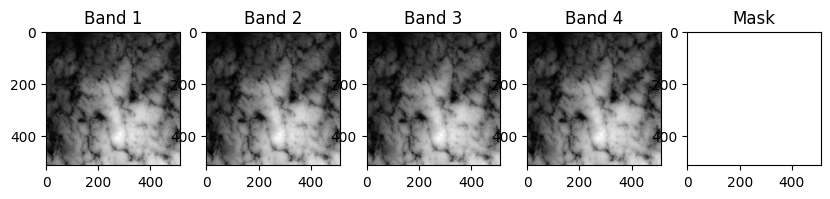

1633it [00:23, 74.92it/s]

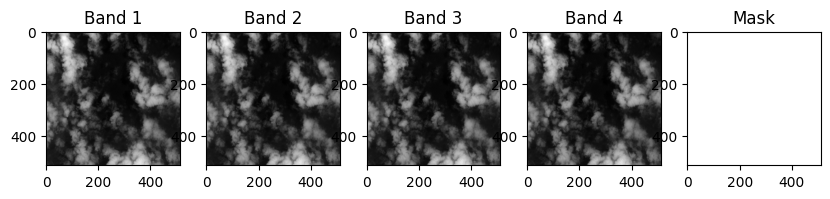

2470it [00:35, 80.46it/s]

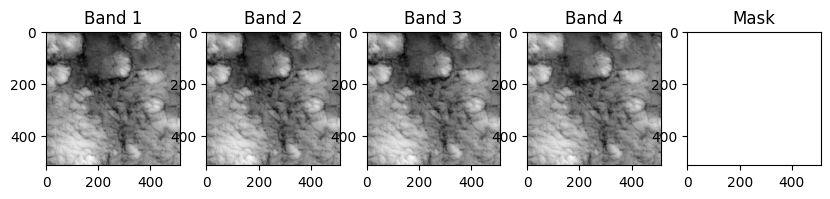

3153it [00:45, 76.16it/s]

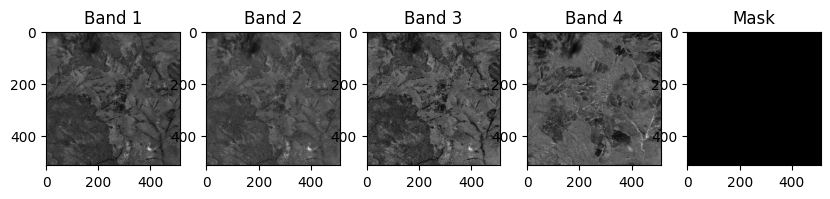

3279it [00:47, 76.24it/s]

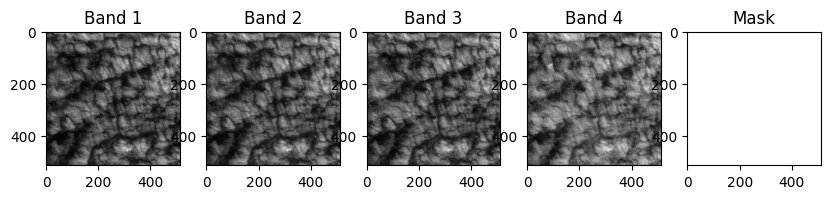

4068it [00:58, 67.59it/s]

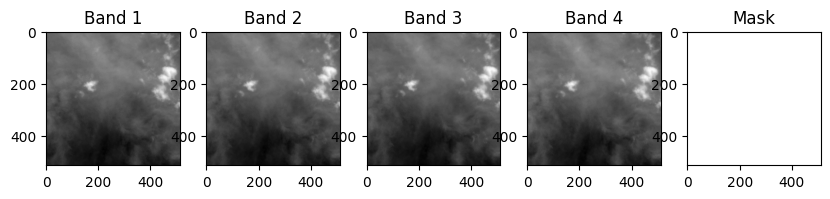

4783it [01:09, 76.51it/s]

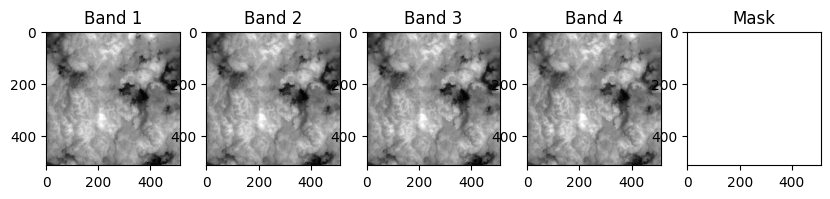

5467it [01:18, 80.20it/s]

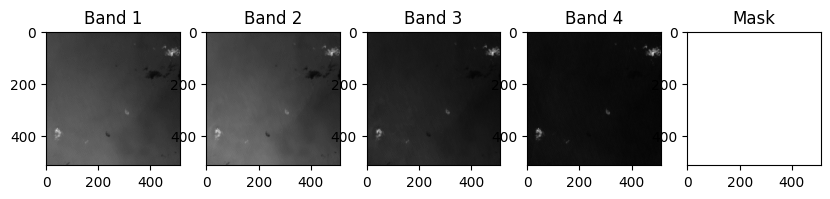

6029it [01:26, 73.36it/s]

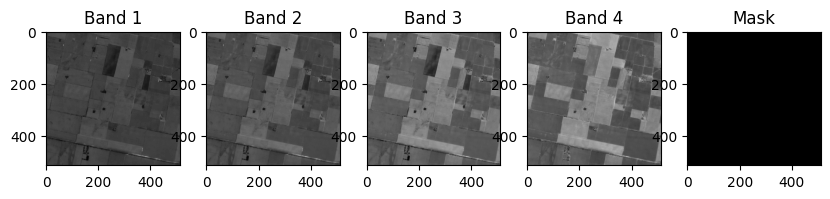

6219it [01:29, 82.04it/s]

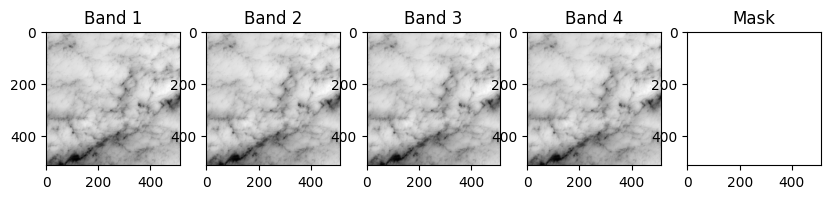

6997it [01:40, 71.00it/s]

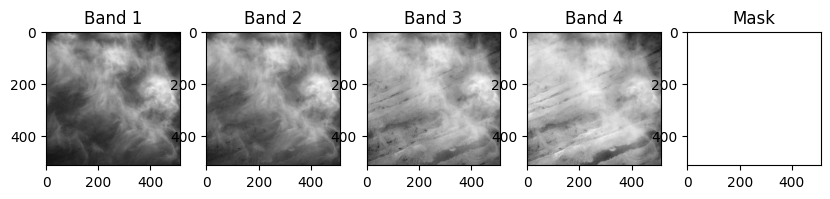

7797it [01:51, 79.23it/s]

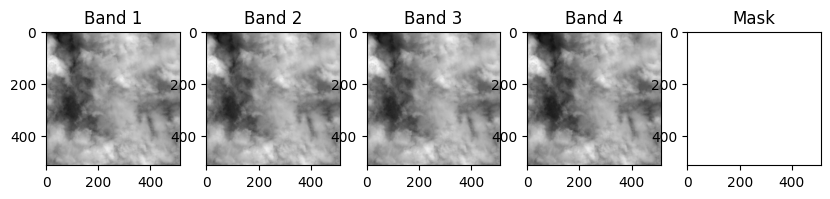

8458it [02:00, 70.28it/s]


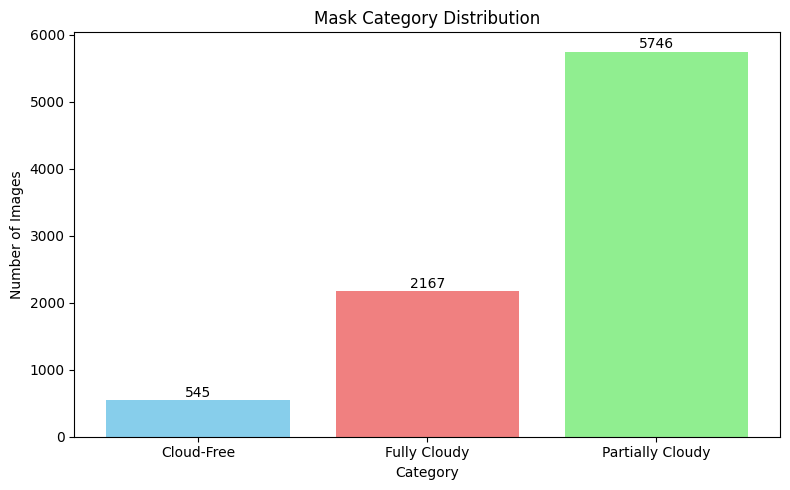

In [9]:
fully_cloud=0
partially_cloud=0
cloud_free=0
for i,file_name in tqdm(enumerate(train_data)):
    file_path=os.path.join(mask_path, file_name)
    img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
    band = img_ds.GetRasterBand(1)
    img = band.ReadAsArray()
    if (np.all(img == 0)):
        cloud_free+=1
        if(cloud_free%200==0):
            display_image(file_name,False)
    elif (np.all(img == 1)):
        fully_cloud+=1
        if(fully_cloud%200==0):
             display_image(file_name,False)
    else:
        partially_cloud+=1
# 📊 Plotting
labels = ['Cloud-Free', 'Fully Cloudy', 'Partially Cloudy']
counts = [cloud_free, fully_cloud, partially_cloud]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Mask Category Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Category')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), ha='center', va='bottom')
plt.tight_layout()
plt.show()